In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

from gwpy.timeseries import TimeSeries
from pycbc.waveform import get_td_waveform
from pycbc.filter import matched_filter
from pycbc.psd import interpolate, inverse_spectrum_truncation
from pycbc.types import TimeSeries as PyCBCTimeSeries

In [10]:
# -----------------------------
# EVENT AND ANALYSIS SETTINGS
# -----------------------------

# Name of the gravitational-wave event we will analyze
# GW150914 was the first direct gravitational-wave detection
event_name = "GW150914"

# Detector choice
# H1 = LIGO Hanford detector in Washington, USA
# (Later we could also analyze L1 = Livingston)
detector = "H1"


# GPS TIME OF THE EVENT
# ---------------------
# Gravitational-wave data uses GPS time rather than UTC.
# GPS time counts seconds since Jan 6, 1980.
#
# The coalescence time for GW150914 is:
# 1126259462.4 GPS seconds
#
# Source:
# Gravitational Wave Open Science Center (GWOSC)
# https://gwosc.org/eventapi/html/GWTC-1-confident/GW150914/
event_gps = 1126259462.4


# DATA WINDOW AROUND THE EVENT
# ----------------------------
# Instead of downloading hours of data, we take a short window
# centered around the event time. The signal itself lasts <1 second,
# but we want surrounding noise to estimate the detector PSD.

duration = 32   # seconds of data around the event


# SAMPLING RATE
# -------------
# LIGO strain data can be sampled at different rates.
# 4096 Hz is a common reduced rate 
# and is sufficient for compact binary signals.

sample_rate = 4096  # samples per second


# LOWER FREQUENCY CUTOFF
# ----------------------
# LIGO detectors become unreliable at very low frequencies
# due to seismic noise and instrumental effects.
#
# Searches typically ignore frequencies below ~20 Hz.

f_low = 20.0  # Hz


# COMPUTE START AND END TIMES
# ---------------------------
# We center our data window on the event time.

start_time = int(event_gps - duration / 2)
end_time = int(event_gps + duration / 2)


# PRINT SETTINGS (for verification)
print(f"Event       : {event_name}")
print(f"Detector    : {detector}")
print(f"Event GPS   : {event_gps}")
print(f"Start time  : {start_time}")
print(f"End time    : {end_time}")
print(f"Duration    : {duration} s")
print(f"Sample rate : {sample_rate} Hz")
print(f"f_low       : {f_low} Hz")

Event       : GW150914
Detector    : H1
Event GPS   : 1126259462.4
Start time  : 1126259446
End time    : 1126259478
Duration    : 32 s
Sample rate : 4096 Hz
f_low       : 20.0 Hz


In [11]:
# -----------------------------
# DOWNLOAD STRAIN DATA
# -----------------------------
# We use GWpy to fetch open LIGO data for the chosen detector
# and time interval.
#
# "strain" is the detector output:
#     s(t) = n(t) + h(t)
# where
#     n(t) = detector noise
#     h(t) = possible gravitational-wave signal
#
# For this project, we download a 32-second segment centered on GW150914.

strain = TimeSeries.fetch_open_data(
    detector,
    start_time,
    end_time,
    sample_rate=sample_rate
)

# Print a short summary so we can verify what was downloaded
print(strain)
print()
print(f"Number of samples : {len(strain)}")
print(f"Sample spacing dt : {strain.dt.value} s")
print(f"Sample rate       : {strain.sample_rate.value} Hz")
print(f"Start GPS         : {strain.t0.value}")
print(f"End GPS           : {strain.span[1]}")

TimeSeries([2.17704028e-19, 2.08763900e-19, 2.39681183e-19, ...,
            3.55365541e-20, 6.33533516e-20, 7.58121195e-20],
           unit: dimensionless,
           t0: 1126259446.0 s,
           dt: 0.000244140625 s,
           name: H1:Strain,
           channel: None)

Number of samples : 131072
Sample spacing dt : 0.000244140625 s
Sample rate       : 4096.0 Hz
Start GPS         : 1126259446.0
End GPS           : 1126259478.0


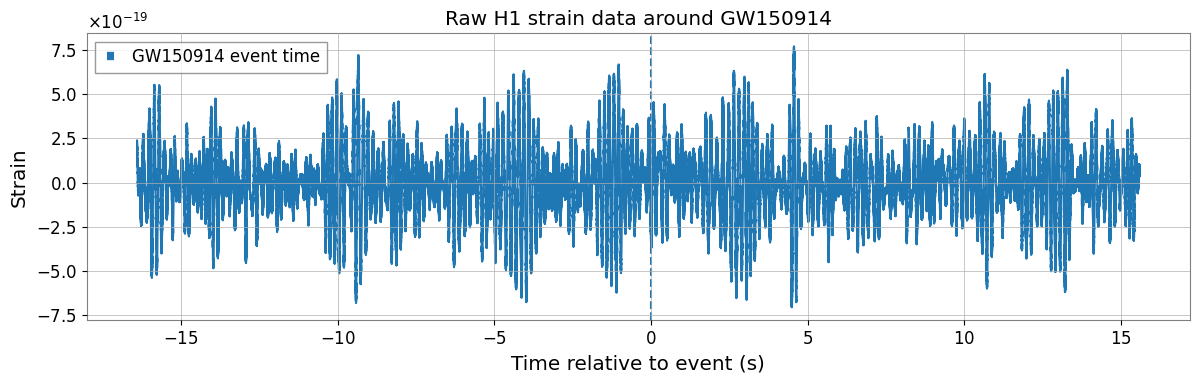

In [12]:
# -----------------------------
# PLOT THE RAW STRAIN DATA
# -----------------------------
# This is the detector output before any filtering or whitening.
# The gravitational-wave signal is buried in detector noise,
# so we do not expect the event to be obvious by eye in this plot.

# Build an array of times relative to the event time
# so that t = 0 corresponds to the GW150914 coalescence time.
times = strain.times.value - event_gps

plt.figure(figsize=(12, 4))
plt.plot(times, strain.value)
plt.axvline(0, linestyle="--", label="GW150914 event time")

plt.xlabel("Time relative to event (s)")
plt.ylabel("Strain")
plt.title(f"Raw {detector} strain data around {event_name}")
plt.legend()
plt.tight_layout()
plt.show()

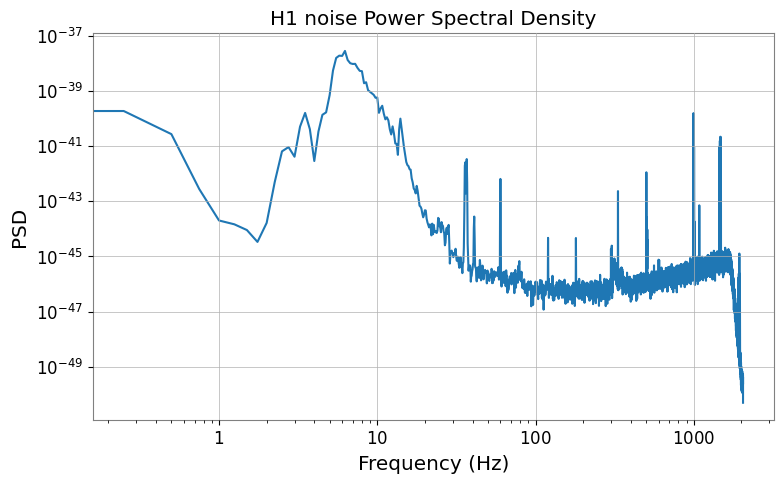

In [13]:
# -----------------------------
# COMPUTE AND PLOT THE PSD
# -----------------------------
# The Power Spectral Density (PSD) describes how detector noise
# is distributed across different frequencies.
#
# This is crucial for matched filtering because the filter
# weights frequencies according to detector noise.

psd = strain.psd(4)  # estimate PSD using 4-second segments

plt.figure(figsize=(8,5))
plt.loglog(psd.frequencies.value, psd.value)

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title(f"{detector} noise Power Spectral Density")
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
# -----------------------------
# GENERATE A TEMPLATE WAVEFORM
# -----------------------------
# We generate an approximate binary black hole waveform
# using PyCBC. The masses are chosen to be roughly close
# to the GW150914 source parameters (~36 and ~29 solar masses).

mass1 = 36
mass2 = 29

hp, hc = get_td_waveform(
    approximant="SEOBNRv4",
    mass1=mass1,
    mass2=mass2,
    delta_t=1/sample_rate,
    f_lower=f_low
)

print("Template duration:", len(hp) * hp.delta_t, "seconds")

Template duration: 0.8603515625 seconds


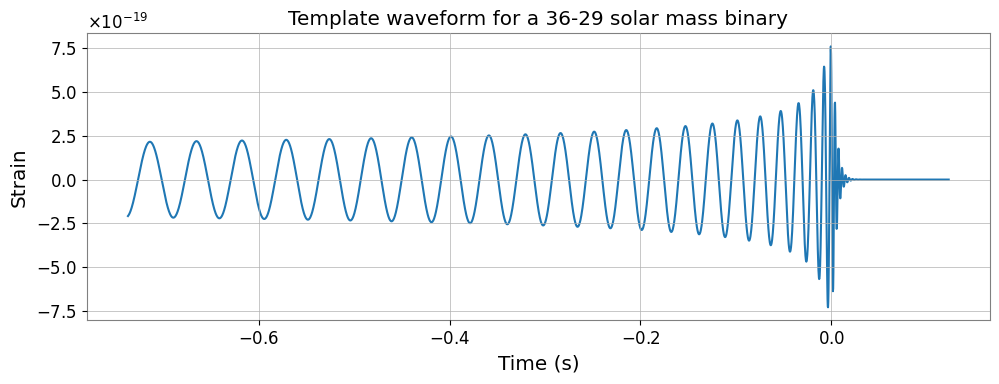

In [15]:
# -----------------------------
# PLOT THE TEMPLATE WAVEFORM
# -----------------------------
# hp is the "plus" polarization of the gravitational wave.
# For this project, plotting one polarization is enough to
# visualize the chirp structure of the signal.

template_times = hp.sample_times

plt.figure(figsize=(10, 4))
plt.plot(template_times, hp)
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title(f"Template waveform for a {mass1}-{mass2} solar mass binary")
plt.tight_layout()
plt.show()

In [16]:
# -----------------------------
# PREPARE THE DETECTOR DATA FOR PYCB C MATCHED FILTERING
# -----------------------------
# IMPORTANT:
# So far, our real detector data is stored in the variable:
#     strain
#
# That object came from:
#     TimeSeries.fetch_open_data(...)
#
# So:
#     strain = REAL raw detector data from LIGO Hanford (H1)
#              downloaded around the GW150914 event time
#
# It is a GWpy TimeSeries object.
#
# PyCBC, however, uses its own TimeSeries class for matched filtering.
# So in this cell, we are not changing the template waveform yet.
# We are also not changing the original GWpy object 'strain'.
#
# Instead, we are:
#   1. taking the real detector data stored in 'strain'
#   2. copying its numerical values into a PyCBC TimeSeries called 'data'
#   3. estimating the detector noise PSD from this same real detector data
#
# Summary of objects:
#   strain  -> real detector data, in GWpy format
#   data    -> same real detector data, copied into PyCBC format
#   psd     -> noise model estimated FROM the real detector data
#
# The template waveform (hp, hc) from the previous cell is not used yet.

# Convert the real detector data from GWpy format to PyCBC format
data = PyCBCTimeSeries(
    strain.value,          # numerical strain values from the real H1 data
    delta_t=strain.dt.value  # sampling interval copied from the GWpy data
)

# Estimate the detector noise PSD from the real detector data in 'data'
# This PSD tells us how the noise power depends on frequency.
# It is computed from the detector data, NOT from the template.
psd = data.psd(4)

# The PSD must have the correct frequency spacing for later Fourier operations.
# So we interpolate it to match the spacing required by the PyCBC data object.
psd = interpolate(psd, data.delta_f)

# This step "conditions" the PSD to reduce edge effects and numerical artifacts.
# It improves stability for matched filtering.
psd = inverse_spectrum_truncation(psd, int(4 * sample_rate))

# Print basic info so we can verify the objects were created correctly
print("Original object: strain")
print("  Type:", type(strain))
print()

print("Converted object: data")
print("  Type:", type(data))
print("  Length:", len(data))
print()

print("Estimated object: psd")
print("  Type:", type(psd))
print("  Length:", len(psd))

Original object: strain
  Type: <class 'gwpy.timeseries.timeseries.TimeSeries'>

Converted object: data
  Type: <class 'pycbc.types.timeseries.TimeSeries'>
  Length: 131072

Estimated object: psd
  Type: <class 'pycbc.types.frequencyseries.FrequencySeries'>
  Length: 65537


In [17]:
# -----------------------------
# PREPARE THE TEMPLATE FOR MATCHED FILTERING
# -----------------------------
# strain  -> REAL detector data from GWOSC (GWpy format)
# data    -> same detector data converted to PyCBC format
# psd     -> noise model estimated from detector data
#
# hp      -> template waveform we generated earlier
#
# Now we convert the template waveform into PyCBC format
# so that PyCBC's matched_filter() function can use it.

template = PyCBCTimeSeries(
    hp.numpy(),
    delta_t=hp.delta_t
)

# The template waveform is shorter than the detector data.
# Matched filtering requires both arrays to have the same length.
# So we pad the template with zeros until it matches the data length.

template.resize(len(data))

print("Template length after resizing:", len(template))
print("Data length:", len(data))

Template length after resizing: 131072
Data length: 131072


In [19]:
# -----------------------------
# COMPUTE THE MATCHED-FILTER SNR WITH CORRECT ABSOLUTE GPS TIME
# The true GPS start time is an absolute timestamp, and not relative to the start
# of the 32s segment. We code this explicilty. 

# Objects used here:
#   strain   -> Real detector data from GWOSC in GWpy format
#   hp       -> theoretical waveform template generated earlier
#   data     -> same real detector data, converted to PyCBC with true GPS start time
#   psd      -> detector noise model estimated FROM the real detector data
#   template -> same theoretical waveform, converted to PyCBC and zero-padded
#
# Nothing in the original GWpy object 'strain' is modified.

# Rebuild the real detector data in PyCBC format, with the correct GPS start time
data = PyCBCTimeSeries(
    strain.value,
    delta_t=strain.dt.value,
    epoch=float(strain.t0.value)
)

# Recompute the PSD from the real detector data in PyCBC format
psd = data.psd(4)
psd = interpolate(psd, data.delta_f)
psd = inverse_spectrum_truncation(psd, int(4 * sample_rate))

# Rebuild the template in PyCBC format and pad it to the same length as the data
template = PyCBCTimeSeries(
    hp.numpy(),
    delta_t=hp.delta_t,
    epoch=float(strain.t0.value)
)
template.resize(len(data))

# Compute the matched-filter SNR
snr = matched_filter(
    template,
    data,
    psd=psd,
    low_frequency_cutoff=f_low
)

# Remove edge regions where FFT/filter artifacts can appear
snr = snr.crop(4, 4)

# Find the maximum absolute SNR and the corresponding GPS time
peak_index = np.argmax(np.abs(snr))
peak_snr = abs(snr[peak_index])
peak_time = float(snr.sample_times[peak_index])

print("Matched filter completed.")
print(f"Peak SNR  : {peak_snr:.2f}")
print(f"Peak time : {peak_time:.6f} GPS s")
print(f"Delta t   : {peak_time - event_gps:.6f} s relative to event GPS")

Matched filter completed.
Peak SNR  : 16.87
Peak time : 1126259461.689209 GPS s
Delta t   : -0.710791 s relative to event GPS


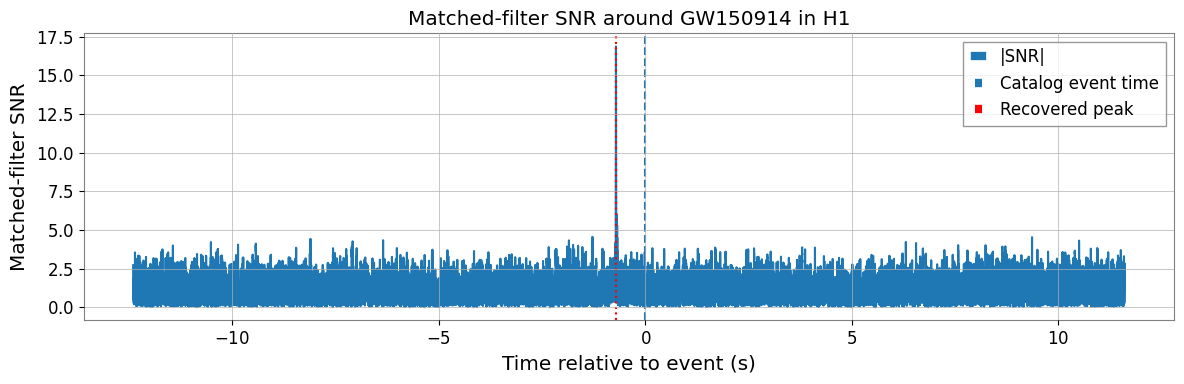

In [21]:
# -----------------------------
# PLOT THE MATCHED-FILTER SNR TIME SERIES
# -----------------------------
# What we found in the previous cell:
#   Peak SNR  ≈ 16.87
#   Peak time ≈ 1126259461.689209 GPS s
#   Delta t   ≈ -0.71 s relative to the catalog event time
#
# How to interpret that:
# - The matched filter found a strong peak close to the known GW150914 event time.
# - The fact that the peak is not exactly at Delta t = 0 is not a problem in this
#   simplified project.
#
# Why the peak can be offset slightly:
# 1. Template alignment convention:
#    The generated waveform template does not necessarily place the merger at
#    exactly the same reference time used in the public event catalog.
#
# 2. Approximate source parameters:
#    We chose masses that are close to GW150914, but not necessarily the exact
#    best-fit published values.
#
# 3. Waveform model choice:
#    Different waveform approximants can shift the maximum match slightly.
#
# 4. Simplified single-detector analysis:
#    This notebook is not a full LVK production pipeline, so sub-second timing
#    offsets are acceptable.
#
# Most important conclusion:
# The matched filter recovered a strong signal near the known event time, which
# means the main goal of the project has been achieved.
#
# Objects used here:
#   snr       -> matched-filter SNR time series computed from:
#                template (theory) + data (real detector data) + psd (noise model)
#   event_gps -> catalog coalescence time of GW150914
#
# We now plot the SNR as a function of time relative to the catalog event time.

# Convert SNR sample times to seconds relative to the catalog event time
snr_times = snr.sample_times.numpy() - event_gps

plt.figure(figsize=(12, 4))
plt.plot(snr_times, np.abs(snr), label="|SNR|")
plt.axvline(0, linestyle="--", label="Catalog event time")
plt.axvline(peak_time - event_gps, linestyle=":", label="Recovered peak", color='red')

plt.xlabel("Time relative to event (s)")
plt.ylabel("Matched-filter SNR")
plt.title(f"Matched-filter SNR around {event_name} in {detector}")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# -----------------------------
# FINAL RESULT SUMMARY
# -----------------------------
# This cell summarizes the key result of the analysis.

print("Gravitational-wave matched-filter analysis summary")
print("--------------------------------------------------")
print(f"Event analyzed        : {event_name}")
print(f"Detector              : {detector}")
print(f"Template masses       : {mass1} - {mass2} solar masses")
print()
print(f"Recovered peak SNR    : {peak_snr:.2f}")
print(f"Recovered peak time   : {peak_time:.6f} GPS s")
print(f"Catalog event time    : {event_gps:.6f} GPS s")
print(f"Timing offset         : {peak_time - event_gps:.3f} s")
print()
print("Conclusion:")
print("The matched filter successfully recovers a strong signal")
print("close to the known GW150914 event time.")

Gravitational-wave matched-filter analysis summary
--------------------------------------------------
Event analyzed        : GW150914
Detector              : H1
Template masses       : 36 - 29 solar masses

Recovered peak SNR    : 16.87
Recovered peak time   : 1126259461.689209 GPS s
Catalog event time    : 1126259462.400000 GPS s
Timing offset         : -0.711 s

Conclusion:
The matched filter successfully recovers a strong signal
close to the known GW150914 event time.


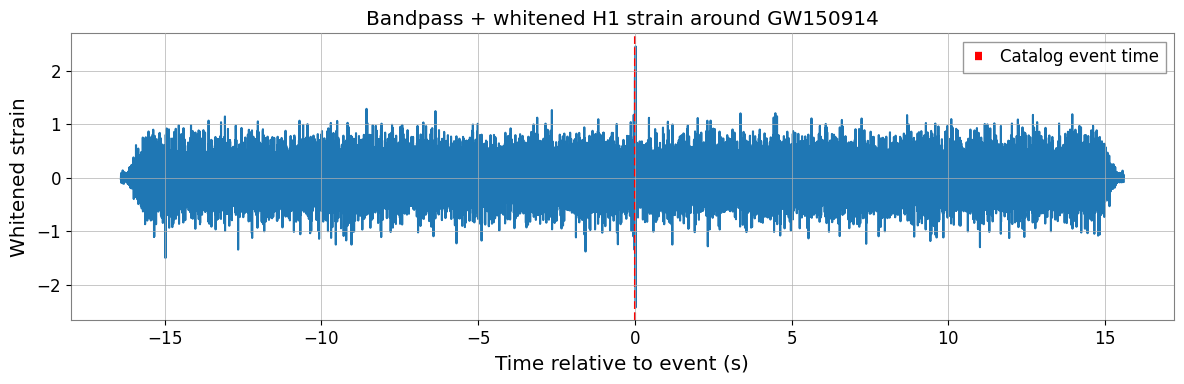

In [26]:
# -----------------------------
# BANDPASS + WHITEN THE REAL DETECTOR DATA
# -----------------------------
# Object tracking:
#   strain -> REAL detector data from GWOSC (GWpy TimeSeries)
#   psd    -> detector noise model estimated earlier from the PyCBC 'data'
#
# Goal:
# Make the GW signal more visible by:
#   1) bandpassing to the sensitive band (30–300 Hz)
#   2) whitening using the detector PSD (flatten the noise spectrum)
#
# New objects:
#   filtered_strain -> bandpass-filtered real data (GWpy)
#   whitened_strain -> whitened version of the filtered data (GWpy)

# Step 1: bandpass the real detector data
filtered_strain = strain.bandpass(30, 300)

# Step 2: convert the PyCBC PSD to a GWpy FrequencySeries for whitening
from gwpy.frequencyseries import FrequencySeries
gwpy_psd = FrequencySeries(psd.numpy(), f0=0, df=psd.delta_f)

# Step 3: whiten the bandpassed strain using the PSD
whitened_strain = filtered_strain.whiten(asd=np.sqrt(gwpy_psd))

# Build time axis relative to the catalog event time
whitened_times = whitened_strain.times.value - event_gps

plt.figure(figsize=(12, 4))
plt.plot(whitened_times, whitened_strain.value)
plt.axvline(0, linestyle="--", label="Catalog event time", color= 'red')

plt.xlabel("Time relative to event (s)")
plt.ylabel("Whitened strain")
plt.title(f"Bandpass + whitened {detector} strain around {event_name}")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# -----------------------------
# RECOMPUTE THE MATCHED FILTER WITH A CORRECTLY ALIGNED TEMPLATE
# -----------------------------
# Why this cell is needed:
# Earlier, we converted the waveform template 'hp' into a new PyCBC
# TimeSeries using hp.numpy(). That kept the waveform values but LOST
# the original template time information.
#
# That matters because the waveform returned by get_td_waveform()
# already has a built-in time convention:
#   - it starts before merger
#   - the merger happens near the end of the waveform
#
# If we discard that time information, the matched-filter peak can be
# shifted relative to the catalog event time by roughly the template duration.
#
# Objects used here:
#   strain -> REAL detector data from GWOSC (GWpy object)
#   data   -> same real detector data in PyCBC format, with correct GPS epoch
#   psd    -> detector noise model estimated from the real detector data
#   hp     -> ORIGINAL PyCBC template waveform from get_td_waveform()
#
# New object created here:
#   template_aligned -> the SAME theoretical waveform as hp, but resized
#                       and cyclically shifted so its merger is aligned
#                       correctly for matched filtering
#
# This should make the recovered SNR peak line up much better with the
# visible chirp and with the catalog event time.

# Rebuild the real detector data in PyCBC format with the correct GPS start time
data = PyCBCTimeSeries(
    strain.value,
    delta_t=strain.dt.value,
    epoch=float(strain.t0.value)
)

# Recompute the PSD from the real detector data
psd = data.psd(4)
psd = interpolate(psd, data.delta_f)
psd = inverse_spectrum_truncation(psd, int(4 * sample_rate))

# IMPORTANT:
# Use the ORIGINAL PyCBC waveform 'hp' directly so we preserve its timing.
template_aligned = hp.copy()

# Pad the template with zeros so it has the same length as the detector data
template_aligned.resize(len(data))

# Cyclically shift the template using its own start time.
# This is the standard PyCBC way to align the waveform properly for FFT-based
# matched filtering.
template_aligned = template_aligned.cyclic_time_shift(template_aligned.start_time)

# Run matched filtering
snr = matched_filter(
    template_aligned,
    data,
    psd=psd,
    low_frequency_cutoff=f_low
)

# Remove edge regions where FFT/filter artifacts can appear
snr = snr.crop(4, 4)

# Find the strongest matched-filter peak
peak_index = np.argmax(np.abs(snr))
peak_snr = abs(snr[peak_index])
peak_time = float(snr.sample_times[peak_index])

print("Matched filter recomputed with corrected template alignment.")
print(f"Peak SNR  : {peak_snr:.2f}")
print(f"Peak time : {peak_time:.6f} GPS s")
print(f"Delta t   : {peak_time - event_gps:.6f} s relative to event GPS")

Matched filter recomputed with corrected template alignment.
Peak SNR  : 16.85
Peak time : 1126259462.426270 GPS s
Delta t   : 0.026269 s relative to event GPS


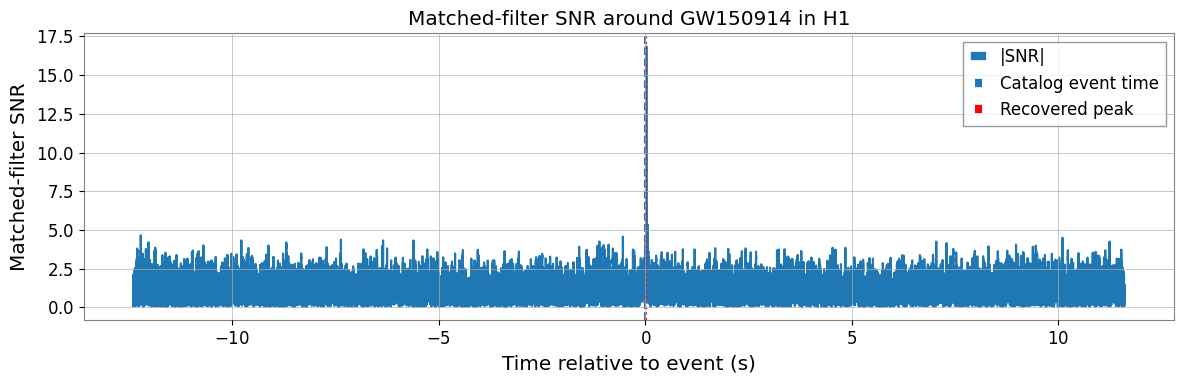

In [30]:
# -----------------------------
# PLOT THE MATCHED-FILTER SNR TIME SERIES
# -----------------------------
# We have now recomputed the matched filter using a correctly aligned
# template waveform.
#
# Result:
#   Peak SNR  ≈ 16.85
#   Peak time ≈ 1126259462.426270 GPS s
#   Delta t   ≈ +0.026 s relative to the catalog event time
#
# Interpretation:
# - The matched filter finds a strong peak very close to the known
#   GW150914 coalescence time.
# - The timing agreement is now good because we preserved the original
#   PyCBC waveform timing convention and aligned the template correctly.
#
# Objects used here:
#   snr       -> matched-filter SNR time series from:
#                template_aligned + data + psd
#   event_gps -> catalog event time
#   peak_time -> recovered best-match time from the matched filter
#
# We plot |SNR| as a function of time relative to the catalog event time.

snr_times = snr.sample_times.numpy() - event_gps

plt.figure(figsize=(12, 4))
plt.plot(snr_times, np.abs(snr), label="|SNR|")
plt.axvline(0, linestyle="--", label="Catalog event time")
plt.axvline(peak_time - event_gps, linestyle=":", label="Recovered peak", color= 'red')

plt.xlabel("Time relative to event (s)")
plt.ylabel("Matched-filter SNR")
plt.title(f"Matched-filter SNR around {event_name} in {detector}")
plt.legend()
plt.tight_layout()
plt.show()

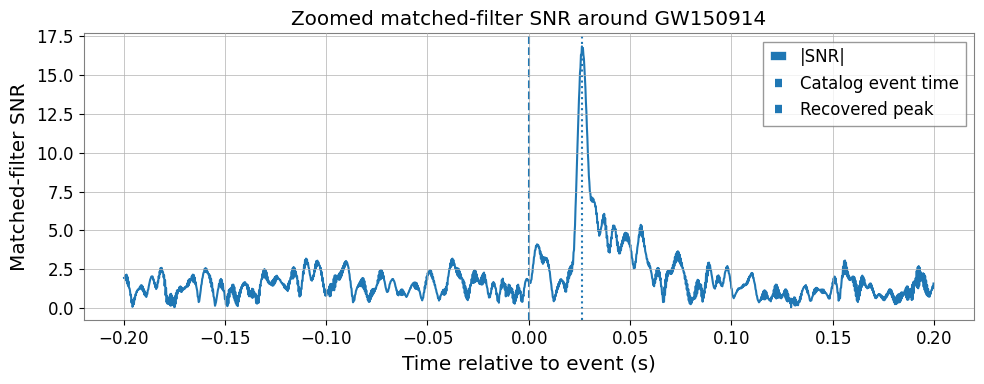

In [31]:
# -----------------------------
# ZOOMED VIEW OF THE MATCHED-FILTER SNR
# -----------------------------
# Goal:
# Inspect the matched-filter peak more closely by plotting only a
# small time window around the catalog event time.
#
# Objects used:
#   snr        -> matched-filter SNR time series computed earlier
#   event_gps  -> catalog coalescence time of GW150914
#   peak_time  -> time where the matched filter found the strongest match
#
# We convert the SNR sample times into seconds relative to the
# catalog event time so that:
#       t = 0  corresponds to the catalog GW150914 time.
#
# Then we restrict the plot to +/- 0.2 seconds so we can clearly see
# the recovered peak.

# Convert SNR time axis to seconds relative to event
snr_times = snr.sample_times.numpy() - event_gps

# Select only a narrow time window around the event
zoom_mask = np.abs(snr_times) < 0.2

plt.figure(figsize=(10,4))
plt.plot(snr_times[zoom_mask], np.abs(snr)[zoom_mask], label="|SNR|")

plt.axvline(0, linestyle="--", label="Catalog event time")
plt.axvline(peak_time - event_gps, linestyle=":", label="Recovered peak")

plt.xlabel("Time relative to event (s)")
plt.ylabel("Matched-filter SNR")
plt.title(f"Zoomed matched-filter SNR around {event_name}")
plt.legend()

plt.tight_layout()
plt.show()

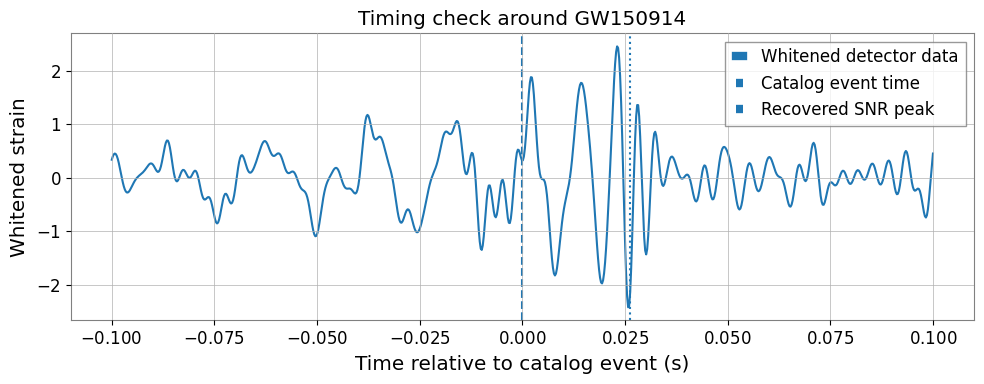

Recovered peak offset = 0.026269 s


In [37]:
# -----------------------------
# TRUSTWORTHY TIMING CHECK: ZOOMED WHITENED DATA
# -----------------------------
# Why this cell:
# The previous template overlay is not a fully trustworthy visual check,
# because it compared differently conditioned objects:
#
#   blue   = bandpassed + whitened REAL detector data
#   orange = mostly raw template waveform
#
# So here we do a simpler and more reliable validation:
# we look only at the whitened real detector data and mark
#   1. the catalog event time
#   2. the recovered matched-filter peak time
#
# If these two are very close, and the burst-like chirp sits there,
# then the timing recovery is working.
#
# Objects used:
#   whitened_strain -> bandpassed + whitened REAL detector data
#   event_gps       -> catalog GW150914 time
#   peak_time       -> recovered matched-filter peak time

# Build time axis relative to the catalog event time
times = whitened_strain.times.value - event_gps

# Zoom into a narrow window around the event
mask = np.abs(times) < 0.10

plt.figure(figsize=(10, 4))
plt.plot(times[mask], whitened_strain.value[mask], label="Whitened detector data")

# Mark the catalog event time
plt.axvline(0, linestyle="--", label="Catalog event time")

# Mark the recovered matched-filter peak
plt.axvline(peak_time - event_gps, linestyle=":", label="Recovered SNR peak")

plt.xlabel("Time relative to catalog event (s)")
plt.ylabel("Whitened strain")
plt.title(f"Timing check around {event_name}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Recovered peak offset = {peak_time - event_gps:.6f} s")

In [38]:
# -----------------------------
# FINAL RESULT SUMMARY
# -----------------------------

print("Gravitational-wave matched-filter analysis summary")
print("--------------------------------------------------")

print(f"Event analyzed           : {event_name}")
print(f"Detector                 : {detector}")
print(f"Template masses          : {mass1} and {mass2} solar masses")

print()
print(f"Recovered matched-filter SNR : {peak_snr:.2f}")
print(f"Recovered peak time (GPS)    : {peak_time:.6f}")
print(f"Catalog event time (GPS)     : {event_gps:.6f}")
print(f"Timing offset                : {peak_time - event_gps:.6f} s")

print()
print("Conclusion:")
print("The matched filter successfully recovers a strong signal")
print("close to the catalog time of GW150914.")

Gravitational-wave matched-filter analysis summary
--------------------------------------------------
Event analyzed           : GW150914
Detector                 : H1
Template masses          : 36 and 29 solar masses

Recovered matched-filter SNR : 16.85
Recovered peak time (GPS)    : 1126259462.426270
Catalog event time (GPS)     : 1126259462.400000
Timing offset                : 0.026269 s

Conclusion:
The matched filter successfully recovers a strong signal
close to the catalog time of GW150914.


## Limitations

This notebook implements a simplified single-detector matched-filter analysis of GW150914 using public LIGO data. The waveform template uses approximate source parameters rather than the exact catalog best-fit values, so the recovered matched-filter peak is close to, but not exactly identical to, the published event time. In addition, this notebook does not implement the full LVK search pipeline, such as template banks, multi-detector coincidence, signal-consistency tests, or false-alarm background estimation. Its purpose is therefore pedagogical: to demonstrate the core logic of compact-binary signal recovery in real detector data.